In [1]:
import os
import pandas as pd
import collections
import plotly.express as px
import plotly.graph_objects as go

In [2]:
model_names = sorted(x[:-4] for x in os.listdir("results/") if x[-4:] == ".txt")

results = collections.defaultdict(list)

for model_name in model_names:
    with open(f"results/{model_name}.txt", "r") as f:
        result = eval(f.read())

        results["Model"].append(model_name)
        
        results["Training Energy (J)"].append(result["Training"]["Energy (J)"])
        results["Training Time (s)"].append(result["Training"]["Time (s)"])
        
        results["RMSE (train)"].append(result["Calling (train)"]["RMSE"])
        results["RMSE (test)"].append(result["Calling (test)"]["RMSE"])
        results["RMSE (sample)"].append(result["Calling (sample)"]["RMSE"])
        
        results["PearsonR (train)"].append(result["Calling (train)"]["PearsonR"])
        results["PearsonR (test)"].append(result["Calling (test)"]["PearsonR"])
        results["PearsonR (sample)"].append(result["Calling (sample)"]["PearsonR"])
        
        results["Calling Time (train) (s)"].append(result["Calling (train)"]["Time (s)"])
        results["Calling Time (test) (s)"].append(result["Calling (test)"]["Time (s)"])
        results["Calling Time (sample) (s)"].append(result["Calling (sample)"]["Time (s)"])
        
        results["Calling Energy (train) (J)"].append(result["Calling (train)"]["Energy (J)"])
        results["Calling Energy (test) (J)"].append(result["Calling (test)"]["Energy (J)"])
        results["Calling Energy (sample) (J)"].append(result["Calling (sample)"]["Energy (J)"])

df = pd.DataFrame(results)
df

,Model,Training Energy (J),Training Time (s),RMSE (train),RMSE (test),RMSE (sample),PearsonR (train),PearsonR (test),PearsonR (sample),Calling Time (train) (s),Calling Time (test) (s),Calling Time (sample) (s),Calling Energy (train) (J),Calling Energy (test) (J),Calling Energy (sample) (J)
0,01linear,17.12,0.010148,0.1026,0.0969,0.1114,0.728,0.788,0.674,0.008820,0.008567,0.008628,16.94,16.54,16.69
1,01linearlasso,16.58,0.009805,0.1479,0.1547,0.1458,0.207,0.186,0.183,0.008990,0.008751,0.008741,16.77,16.65,16.62
2,01linearridgecv,16.54,0.011737,0.1059,0.1043,0.1059,0.714,0.762,0.696,0.008839,0.008593,0.008528,16.59,16.57,16.69
3,02gradboost,23.18,0.501560,0.0954,0.1084,0.0976,0.800,0.745,0.777,0.014182,0.010660,0.010997,17.42,18.50,21.77
4,02histgradboost,59.51,1.595010,0.0549,0.0871,0.0645,0.938,0.834,0.906,0.019158,0.014193,0.014931,26.39,20.67,20.85
5,03decisiontree,19.99,0.035861,0.0000,0.1344,0.0704,1.000,0.626,0.885,0.010235,0.009627,0.008759,32.52,19.73,18.26
6,04randomforest,47.90,1.672281,0.0328,0.0906,0.0522,0.983,0.827,0.945,0.066821,0.032459,0.031324,22.33,24.07,23.03
7,04randomforest2,44.73,0.316052,0.1343,0.1412,0.1328,0.444,0.435,0.439,0.023471,0.017002,0.016815,42.86,21.65,18.19
8,05kneighbours,17.92,0.013317,0.1164,0.1505,0.1228,0.630,0.339,0.553,0.031660,0.015834,0.014485,26.53,21.39,22.49
9,06bagging,27.86,0.181659,0.0407,0.0952,0.0588,0.967,0.797,0.923,0.017704,0.013172,0.012981,25.60,31.10,21.85


In [3]:
## Normalise based on proportion for comparing test/train
TEST_FRACTION = 0.2
df["Calling Time (train) (s)"] /= 1 - TEST_FRACTION # Normalise
df["Calling Time (test) (s)"] /= TEST_FRACTION # Normalise

## Calculate CFP assuming CI of 80.846 gCO2/MJ based on 2023 IEA global estimate
## https://www.iea.org/world/emissions
NOMINAL_CI = 80.846e-6 # gCO2/J
df["Training CFP (gCO2)"] = df["Training Energy (J)"] * NOMINAL_CI
df["Calling CFP (train) (gCO2)"] = df["Calling Energy (train) (J)"] * NOMINAL_CI / (1 - TEST_FRACTION)
df["Calling CFP (test) (gCO2)"] = df["Calling Energy (test) (J)"] * NOMINAL_CI / TEST_FRACTION
df["Calling CFP (sample) (gCO2)"] = df["Calling Energy (sample) (J)"] * NOMINAL_CI / TEST_FRACTION

df = df.sort_values(by = ["RMSE (test)", "Training CFP (gCO2)", ])

df

,Model,Training Energy (J),Training Time (s),RMSE (train),RMSE (test),RMSE (sample),PearsonR (train),PearsonR (test),PearsonR (sample),Calling Time (train) (s),Calling Time (test) (s),Calling Time (sample) (s),Calling Energy (train) (J),Calling Energy (test) (J),Calling Energy (sample) (J),Training CFP (gCO2),Calling CFP (train) (gCO2),Calling CFP (test) (gCO2),Calling CFP (sample) (gCO2)
4,02histgradboost,59.51,1.595010,0.0549,0.0871,0.0645,0.938,0.834,0.906,0.023948,0.070965,0.014931,26.39,20.67,20.85,0.004811,0.002667,0.008355,0.008428
13,09extratrees,43.16,0.956542,0.0000,0.0895,0.0441,1.000,0.827,0.955,0.106872,0.169105,0.036834,39.62,32.37,25.25,0.003489,0.004004,0.013085,0.010207
6,04randomforest,47.90,1.672281,0.0328,0.0906,0.0522,0.983,0.827,0.945,0.083526,0.162295,0.031324,22.33,24.07,23.03,0.003873,0.002257,0.009730,0.009309
9,06bagging,27.86,0.181659,0.0407,0.0952,0.0588,0.967,0.797,0.923,0.022130,0.065860,0.012981,25.60,31.10,21.85,0.002252,0.002587,0.012572,0.008832
0,01linear,17.12,0.010148,0.1026,0.0969,0.1114,0.728,0.788,0.674,0.011025,0.042835,0.008628,16.94,16.54,16.69,0.001384,0.001712,0.006686,0.006747
2,01linearridgecv,16.54,0.011737,0.1059,0.1043,0.1059,0.714,0.762,0.696,0.011049,0.042965,0.008528,16.59,16.57,16.69,0.001337,0.001677,0.006698,0.006747
3,02gradboost,23.18,0.501560,0.0954,0.1084,0.0976,0.800,0.745,0.777,0.017728,0.053300,0.010997,17.42,18.50,21.77,0.001874,0.001760,0.007478,0.008800
12,08adaboost,32.48,0.285859,0.1212,0.1275,0.1212,0.596,0.587,0.571,0.033922,0.086065,0.019027,32.41,21.32,32.53,0.002626,0.003275,0.008618,0.013150
5,03decisiontree,19.99,0.035861,0.0000,0.1344,0.0704,1.000,0.626,0.885,0.012794,0.048135,0.008759,32.52,19.73,18.26,0.001616,0.003286,0.007975,0.007381
7,04randomforest2,44.73,0.316052,0.1343,0.1412,0.1328,0.444,0.435,0.439,0.029339,0.085010,0.016815,42.86,21.65,18.19,0.003616,0.004331,0.008752,0.007353


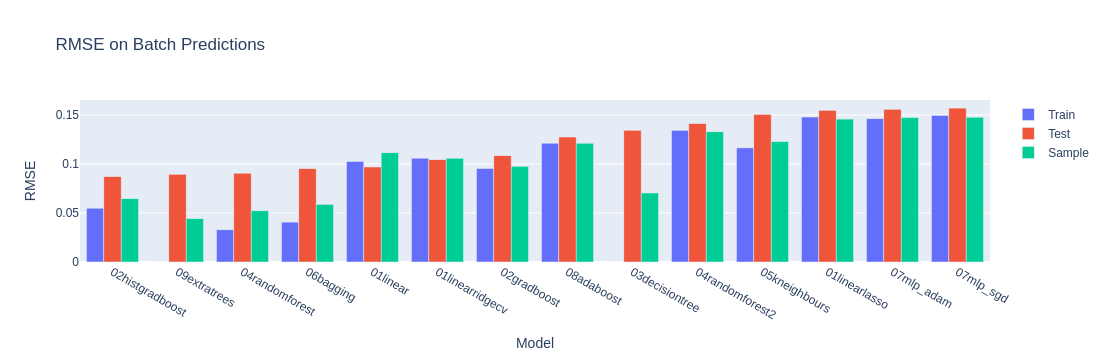

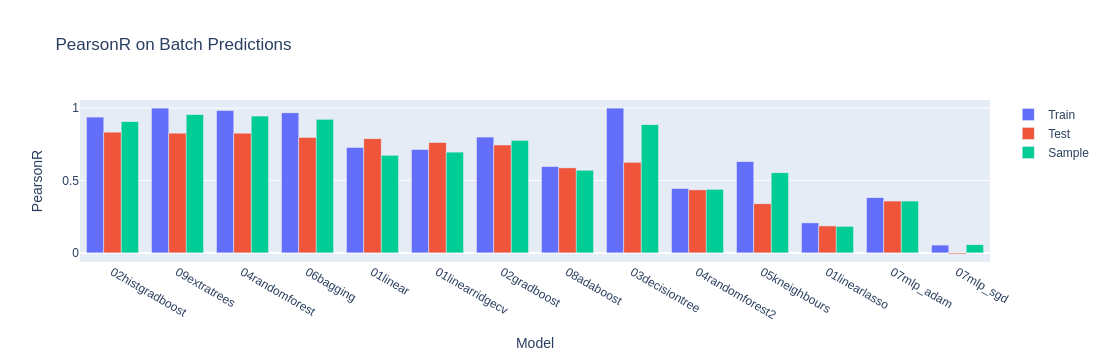

In [4]:
## RMSE on Batch Predictions
fig = go.Figure(data = [
    go.Bar(name = "Train", x = df["Model"], y = df["RMSE (train)"]),
    go.Bar(name = "Test", x = df["Model"], y = df["RMSE (test)"]),
    go.Bar(name = "Sample", x = df["Model"], y = df["RMSE (sample)"]),
])
fig.update_layout(title = "RMSE on Batch Predictions")
fig.update_layout(yaxis_title = "RMSE")
fig.update_layout(xaxis_title = "Model")
fig.update_layout(barmode = "group")
fig.show()


## PearsonR on Batch Predictions
fig = go.Figure(data = [
    go.Bar(name = "Train", x = df["Model"], y = df["PearsonR (train)"]),
    go.Bar(name = "Test", x = df["Model"], y = df["PearsonR (test)"]),
    go.Bar(name = "Sample", x = df["Model"], y = df["PearsonR (sample)"]),
])
fig.update_layout(title = "PearsonR on Batch Predictions")
fig.update_layout(yaxis_title = "PearsonR")
fig.update_layout(xaxis_title = "Model")
fig.update_layout(barmode = "group")
fig.show()

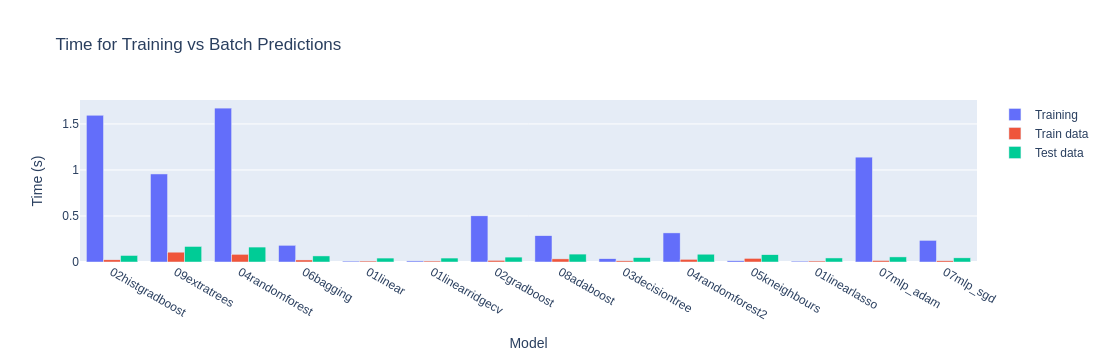

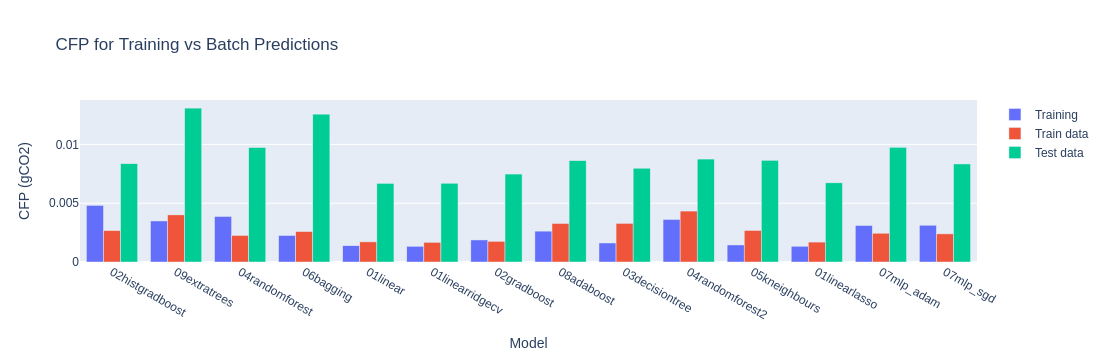

In [5]:
## Time for Training vs Batch Predictions
fig = go.Figure(data = [
    go.Bar(name = "Training", x = df["Model"], y = df["Training Time (s)"]),
    go.Bar(name = "Train data", x = df["Model"], y = df["Calling Time (train) (s)"]),
    go.Bar(name = "Test data", x = df["Model"], y = df["Calling Time (test) (s)"]),
])
fig.update_layout(title = "Time for Training vs Batch Predictions")
fig.update_layout(yaxis_title = "Time (s)")
fig.update_layout(xaxis_title = "Model")
fig.update_layout(barmode = "group")
fig.show()

## CFP for Training vs Batch Predictions
fig = go.Figure(data = [
    go.Bar(name = "Training", x = df["Model"], y = df["Training CFP (gCO2)"]),
    go.Bar(name = "Train data", x = df["Model"], y = df["Calling CFP (train) (gCO2)"]),
    go.Bar(name = "Test data", x = df["Model"], y = df["Calling CFP (test) (gCO2)"]),
])
fig.update_layout(title = "CFP for Training vs Batch Predictions")
fig.update_layout(yaxis_title = "CFP (gCO2)")
fig.update_layout(xaxis_title = "Model")
fig.update_layout(barmode = "group")
fig.show()

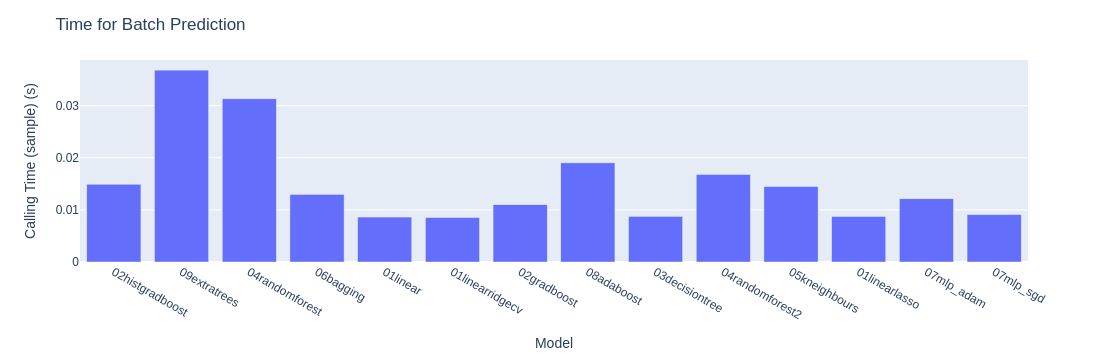

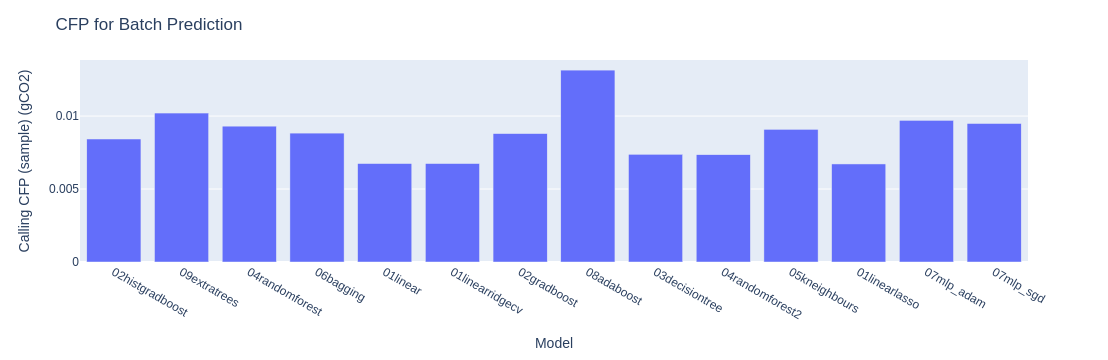

In [6]:
## Time for Batch Prediction
fig = px.bar(df, x = "Model", y = "Calling Time (sample) (s)")
fig.update_layout(title = "Time for Batch Prediction")
fig.show()

## CFP for Batch Prediction
fig = px.bar(df, x = "Model", y = "Calling CFP (sample) (gCO2)")
fig.update_layout(title = "CFP for Batch Prediction")
fig.show()